<a href="https://colab.research.google.com/github/karib3/ML-Engineering/blob/main/Regression/Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Problem Definition
Predict the house price with the given features.

#Data Collection:
Dataset: Ames Housing Dataset
Source: Kaggle

In [ ]:
#Downloading the dataset
import kagglehub
path = kagglehub.dataset_download("prevek18/ames-housing-dataset")

100%|██████████| 185k/185k [00:00<00:00, 16.3MB/s]

Extracting files...


In [ ]:
#Importing essential modules
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#Loading the dataset
acutal_path = path + "/AmesHousing.csv"
df = pd.read_csv(acutal_path)

#Exploratory Data Analysis (EDA)

In [ ]:
df.shape

(2930, 82)

In [ ]:
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [ ]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [ ]:
df.tail()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
2925,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,NaN,8885,Pave,NaN,IR1,Low,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000
2929,2930,924151050,60,RL,74.0,9627,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,11,2006,WD,Normal,188000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Missing %': missing_percent})
print(missing_df)

                Missing  Missing %
Pool QC            2917  99.556314
Misc Feature       2824  96.382253
Alley              2732  93.242321
Fence              2358  80.477816
Mas Vnr Type       1775  60.580205
Fireplace Qu       1422  48.532423
Lot Frontage        490  16.723549
Garage Qual         159   5.426621
Garage Cond         159   5.426621
Garage Yr Blt       159   5.426621
Garage Finish       159   5.426621
Garage Type         157   5.358362
Bsmt Exposure        83   2.832765
BsmtFin Type 2       81   2.764505
Bsmt Cond            80   2.730375
Bsmt Qual            80   2.730375
BsmtFin Type 1       80   2.730375
Mas Vnr Area         23   0.784983
Bsmt Full Bath        2   0.068259
Bsmt Half Bath        2   0.068259
BsmtFin SF 1          1   0.034130
BsmtFin SF 2          1   0.034130
Electrical            1   0.034130
Total Bsmt SF         1   0.034130
Bsmt Unf SF           1   0.034130
Garage Area           1   0.034130
Garage Cars           1   0.034130


In [ ]:
df.dtypes

,0
Order,int64
PID,int64
MS SubClass,int64
MS Zoning,object
Lot Frontage,float64
...,...
Mo Sold,int64
Yr Sold,int64
Sale Type,object
Sale Condition,object


In [ ]:
df.nunique()

,0
Order,2930
PID,2930
MS SubClass,16
MS Zoning,7
Lot Frontage,128
...,...
Mo Sold,12
Yr Sold,5
Sale Type,10
Sale Condition,6


In [ ]:
print("Duplicated rows: ", df.duplicated().sum())

Duplicated rows:  0


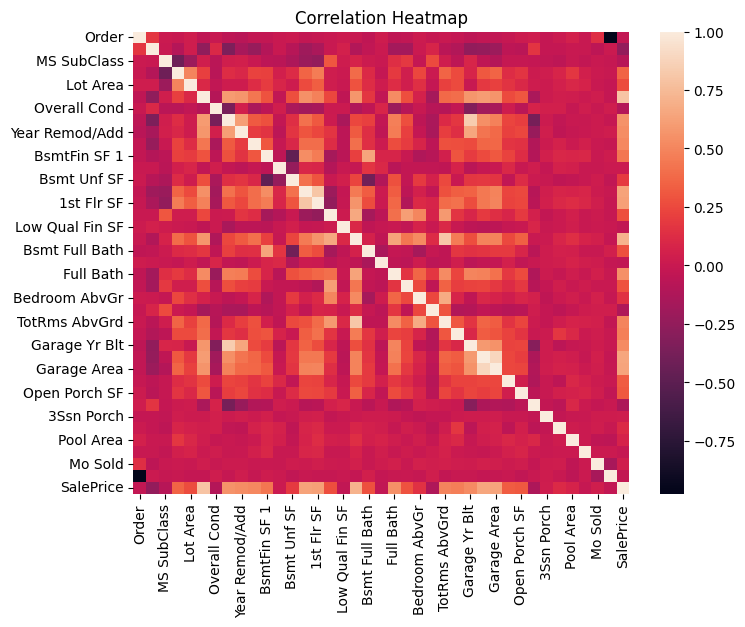

In [ ]:
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr())
plt.title("Correlation Heatmap")
plt.show()

SalePrice          1.000000
Overall Qual       0.799262
Gr Liv Area        0.706780
Garage Cars        0.647877
Garage Area        0.640401
Total Bsmt SF      0.632280
1st Flr SF         0.621676
Year Built         0.558426
Full Bath          0.545604
Year Remod/Add     0.532974
Garage Yr Blt      0.526965
Mas Vnr Area       0.508285
TotRms AbvGrd      0.495474
Fireplaces         0.474558
BsmtFin SF 1       0.432914
Lot Frontage       0.357318
Wood Deck SF       0.327143
Open Porch SF      0.312951
Half Bath          0.285056
Bsmt Full Bath     0.276050
2nd Flr SF         0.269373
Lot Area           0.266549
Bsmt Unf SF        0.182855
Bedroom AbvGr      0.143913
Screen Porch       0.112151
Pool Area          0.068403
Mo Sold            0.035259
3Ssn Porch         0.032225
BsmtFin SF 2       0.005891
Misc Val          -0.015691
Yr Sold           -0.030569
Order             -0.031408
Bsmt Half Bath    -0.035835
Low Qual Fin SF   -0.037660
MS SubClass       -0.085092
Overall Cond      -0

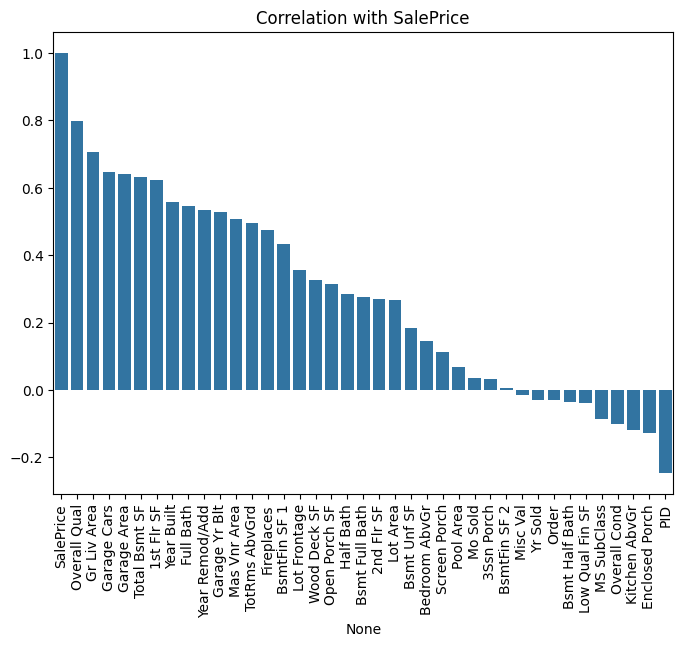

In [ ]:
saleprice_corr = numeric_df.corr()['SalePrice'].sort_values(ascending=False)
print(saleprice_corr)

plt.figure(figsize=(8, 6))
sns.barplot(x=saleprice_corr.index, y=saleprice_corr.values)
plt.title("Correlation with SalePrice")
plt.xticks(rotation=90)
plt.show()

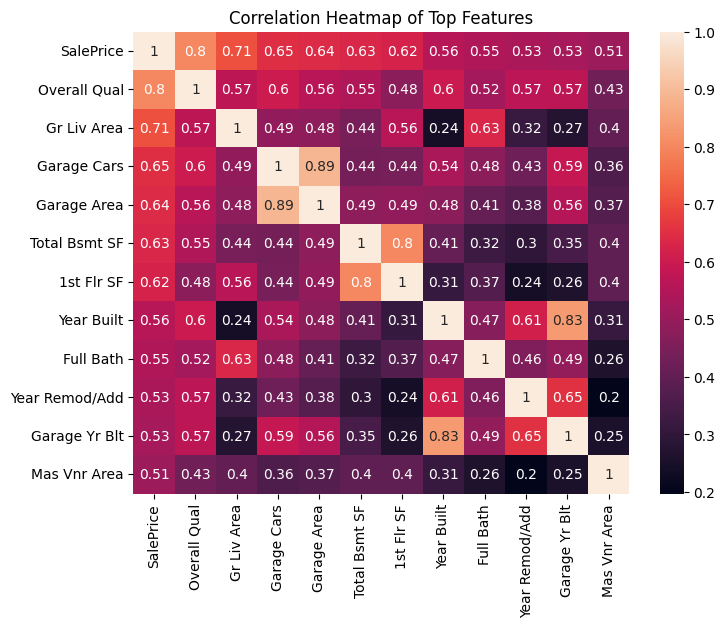

In [ ]:
top_corr = saleprice_corr[abs(saleprice_corr) > 0.5]
plt.figure(figsize=(8, 6))
sns.heatmap(df[top_corr.index].corr(), annot=True)
plt.title("Correlation Heatmap of Top Features")
plt.show()

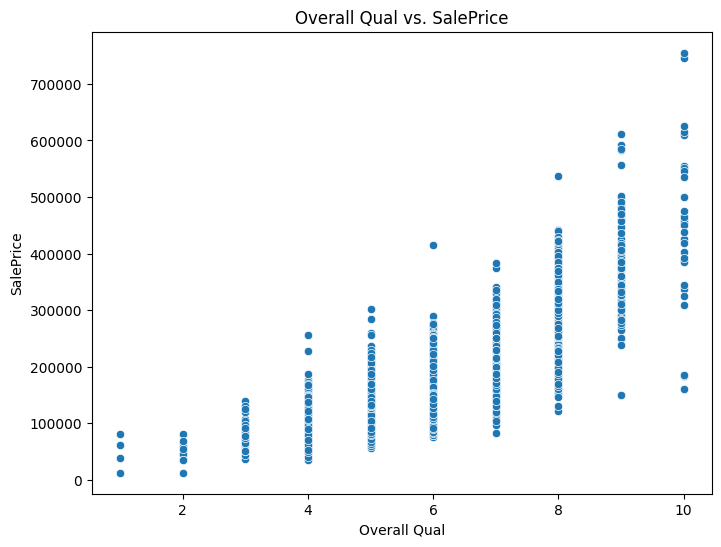

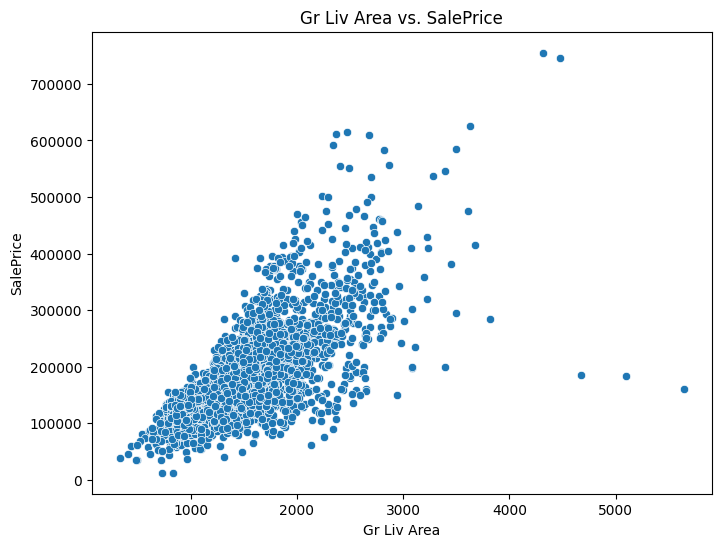

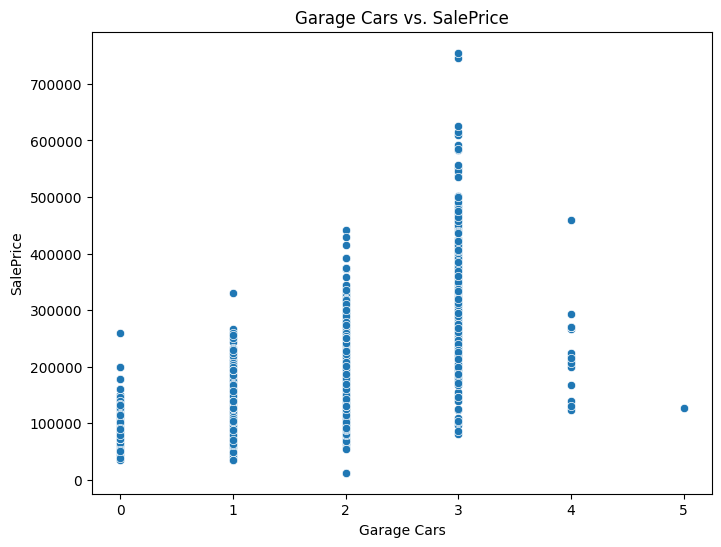

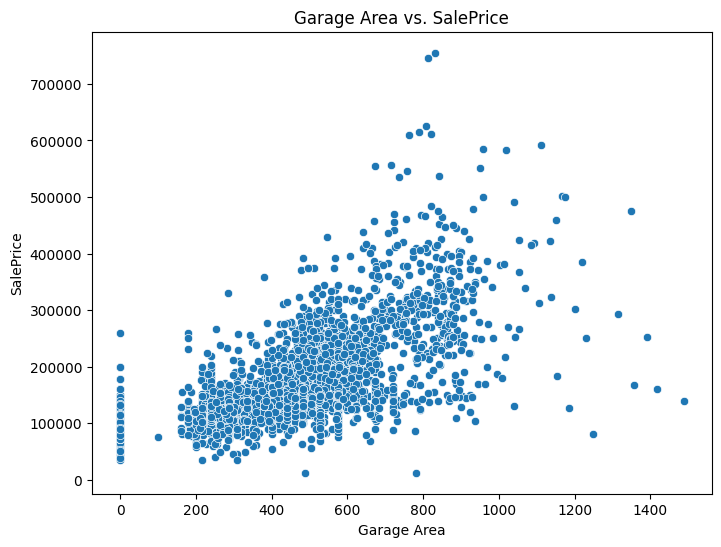

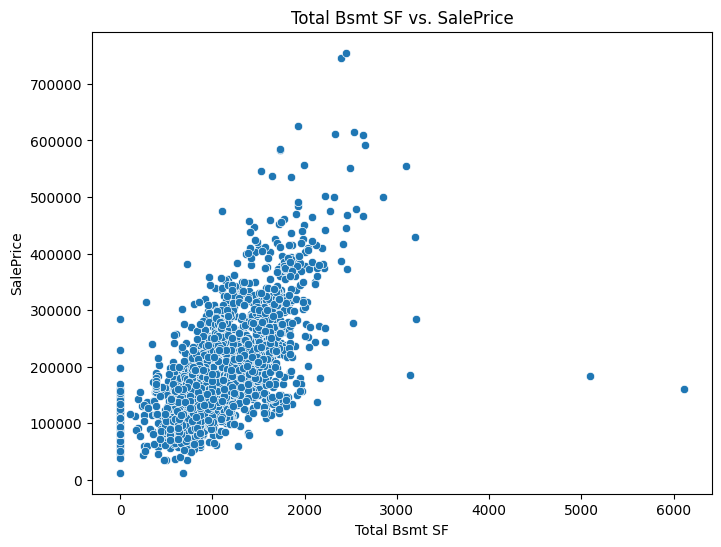

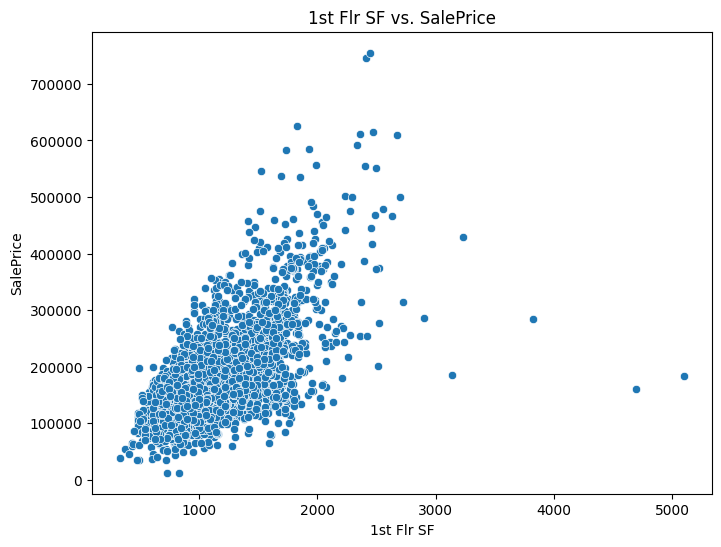

In [ ]:
top_numeric_features = ['Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area', 'Total Bsmt SF', '1st Flr SF']
for feature in top_numeric_features:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=df[feature], y=df['SalePrice'])
    plt.title(f"{feature} vs. SalePrice")
    plt.show()

In [ ]:
categorical_df = df.select_dtypes(include=['object'])
print(categorical_df.nunique().sort_values(ascending=False))

Neighborhood      28
Exterior 2nd      17
Exterior 1st      16
Sale Type         10
Condition 1        9
House Style        8
Functional         8
Roof Matl          8
Condition 2        8
MS Zoning          7
Roof Style         6
BsmtFin Type 1     6
Sale Condition     6
Heating            6
Foundation         6
Garage Type        6
BsmtFin Type 2     6
Lot Config         5
Kitchen Qual       5
Misc Feature       5
Garage Cond        5
Garage Qual        5
Exter Cond         5
Fireplace Qu       5
Bsmt Cond          5
Bldg Type          5
Bsmt Qual          5
Heating QC         5
Electrical         5
Bsmt Exposure      4
Exter Qual         4
Land Contour       4
Lot Shape          4
Mas Vnr Type       4
Pool QC            4
Fence              4
Garage Finish      3
Land Slope         3
Utilities          3
Paved Drive        3
Alley              2
Street             2
Central Air        2
dtype: int64


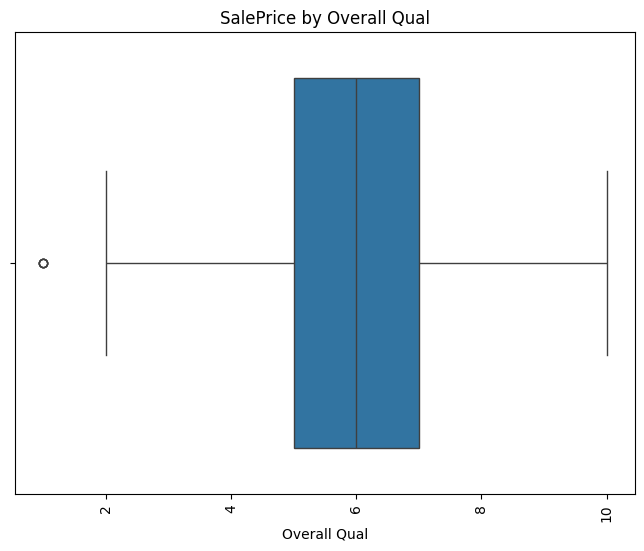

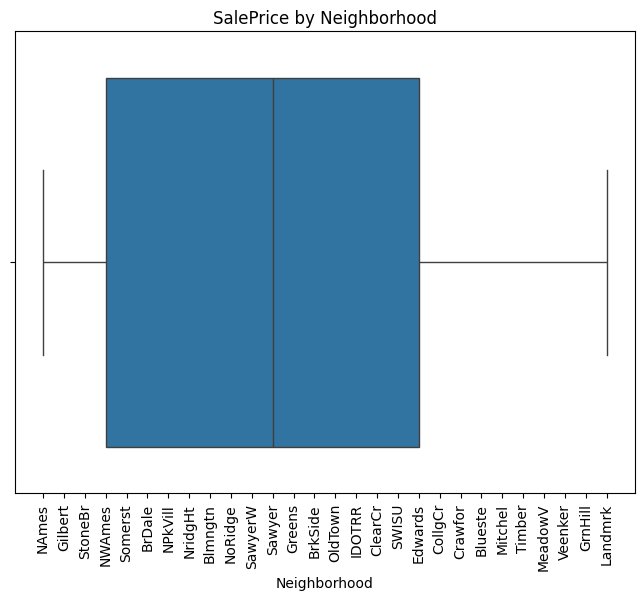

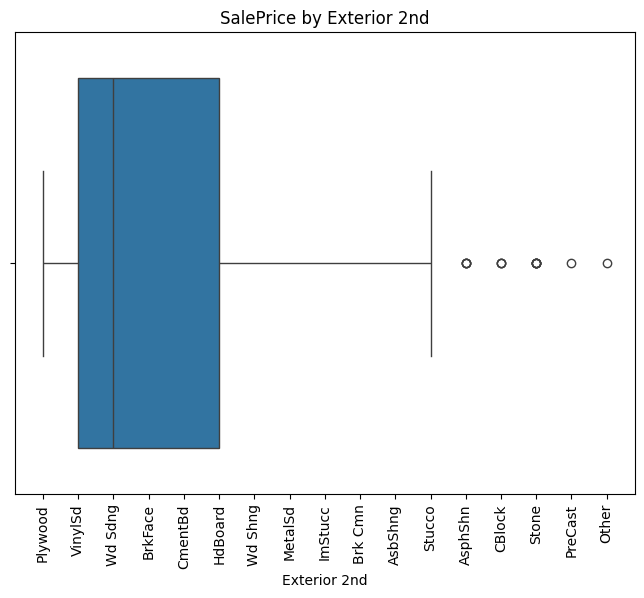

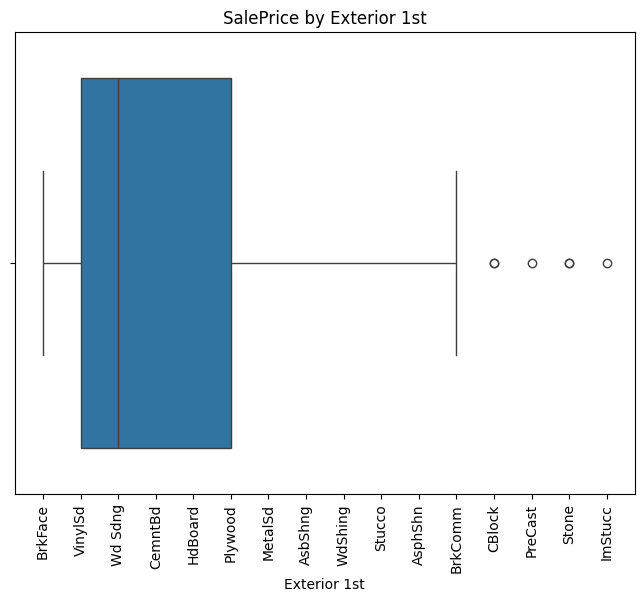

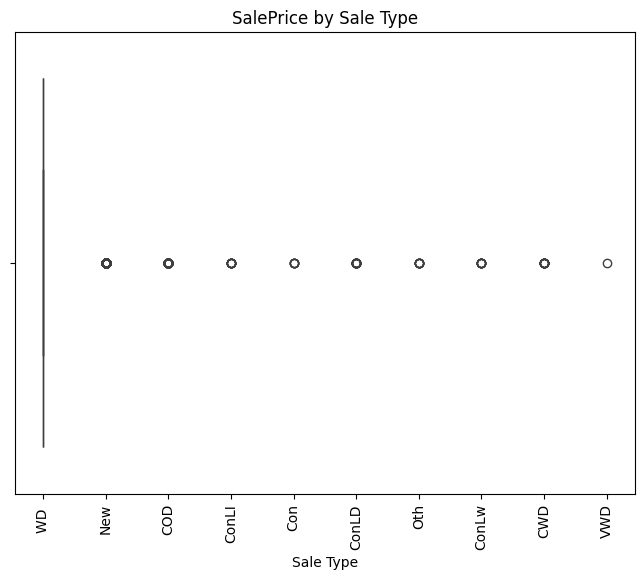

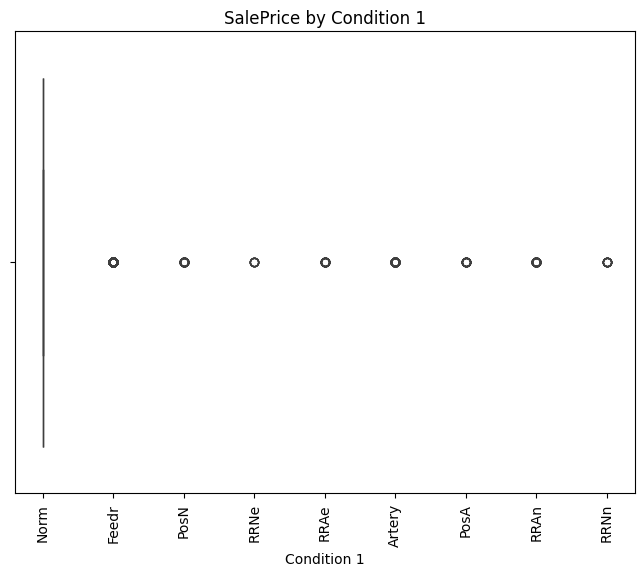

In [ ]:
top_categorical_features = ['Overall Qual', 'Neighborhood', 'Exterior 2nd', 'Exterior 1st', 'Sale Type', 'Condition 1']
for feature in top_categorical_features:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=df[feature])
    plt.title(f"SalePrice by {feature}")
    plt.xticks(rotation=90)
    plt.show()

In [ ]:
df['SalePrice'].describe()

,SalePrice
count,2930.000000
mean,180796.060068
std,79886.692357
min,12789.000000
25%,129500.000000
50%,160000.000000
75%,213500.000000
max,755000.000000


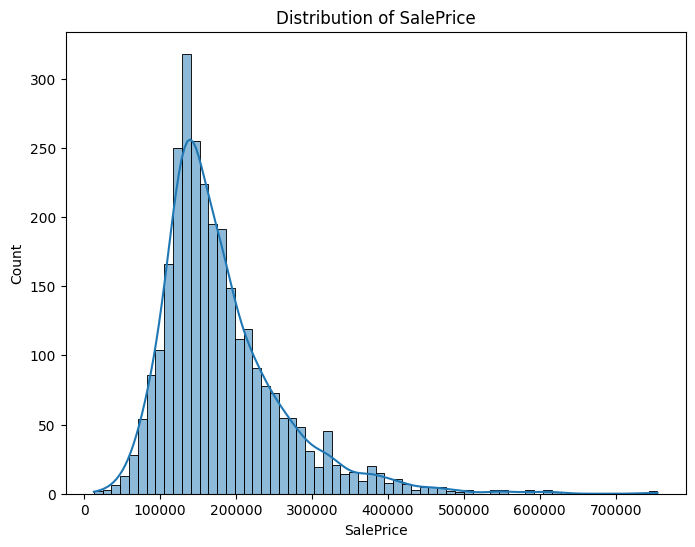

Skewness:  1.7435000757376466


In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(df['SalePrice'], kde=True)
plt.title("Distribution of SalePrice")
plt.show()

print("Skewness: ", df["SalePrice"].skew())

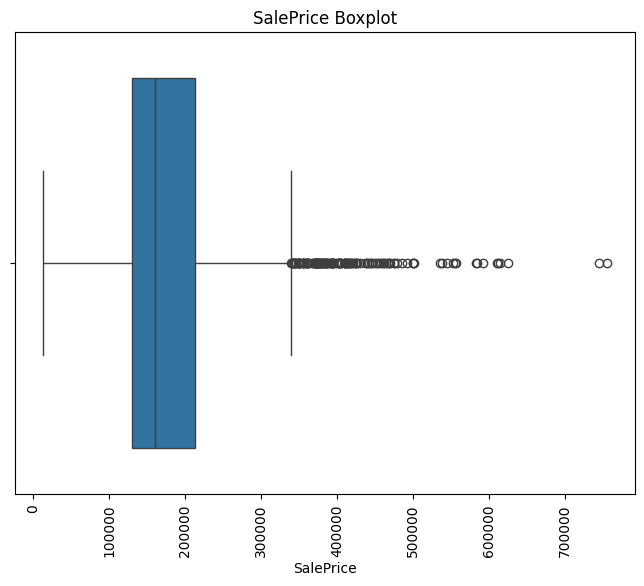

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['SalePrice'])
plt.xticks(rotation=90)
plt.title("SalePrice Boxplot")
plt.show()

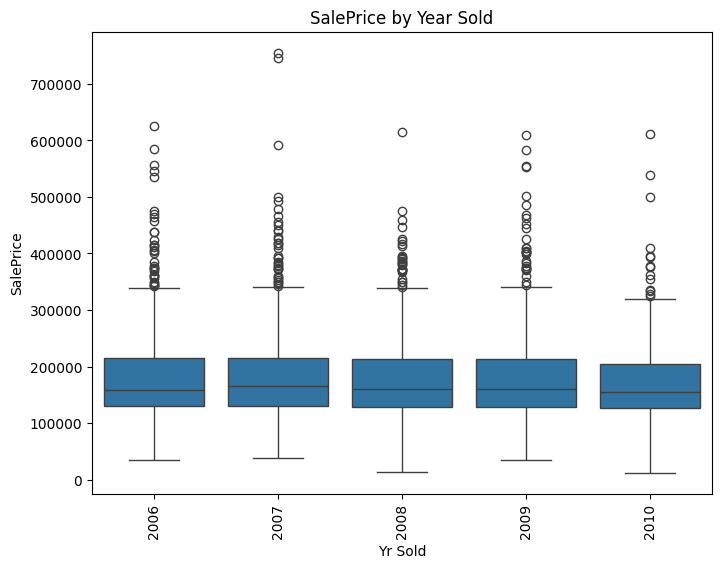

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Yr Sold'], y=df['SalePrice'])
plt.xticks(rotation=90)
plt.title("SalePrice by Year Sold")
plt.show()

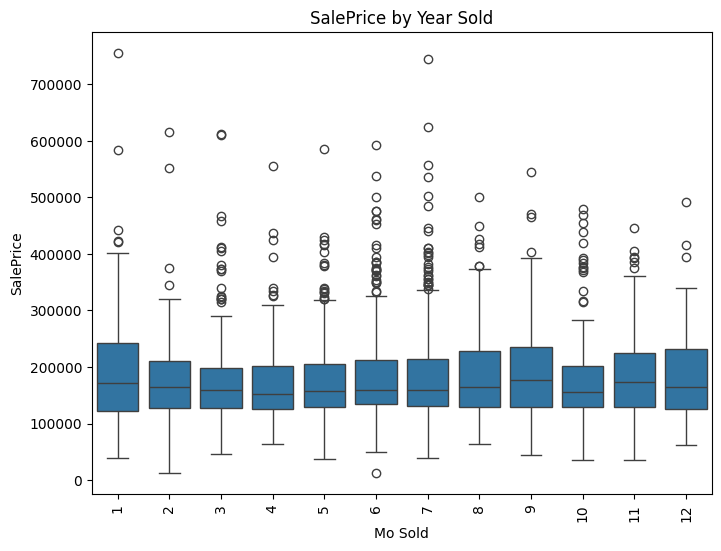

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Mo Sold'], y=df['SalePrice'])
plt.xticks(rotation=90)
plt.title("SalePrice by Year Sold")
plt.show()

#Data Cleaning

In [ ]:
df_clean = df.drop(columns=['Order', 'PID']).copy()
df_clean

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,AllPub,CulDSac,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,20,RL,NaN,8885,Pave,NaN,IR1,Low,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


In [ ]:
numeric_cols = df_clean.select_dtypes(include='number')
categorical_cols = df_clean.select_dtypes(include='object')

numeric_list = numeric_cols.columns.tolist()
print("Numeric columns: ", len(numeric_list))
print(numeric_list)

categorical_list = categorical_cols.columns.tolist()
print("Categorical columns: ", len(categorical_list))
print(categorical_list)

Numeric columns:  2930
['MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold', 'SalePrice']
Categorical columns:  2930
['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', '

In [ ]:
numeric_info = pd.DataFrame({
    'dtype': numeric_cols.dtypes,
    'missing': numeric_cols.isnull().sum(),
    'unique': numeric_cols.nunique(),
    'min': numeric_cols.min(),
    'max': numeric_cols.max()
})

low_cardinality= (numeric_info[numeric_info['unique']<=20].sort_values('unique'))
low_cardinality

,dtype,missing,unique,min,max
Half Bath,int64,0,3,0.0,2.0
Bsmt Half Bath,float64,2,3,0.0,2.0
Bsmt Full Bath,float64,2,4,0.0,3.0
Kitchen AbvGr,int64,0,4,0.0,3.0
Fireplaces,int64,0,5,0.0,4.0
Yr Sold,int64,0,5,2006.0,2010.0
Full Bath,int64,0,5,0.0,4.0
Garage Cars,float64,1,6,0.0,5.0
Bedroom AbvGr,int64,0,8,0.0,8.0
Overall Cond,int64,0,9,1.0,9.0


In [ ]:
numeric_categorical = ['MS SubClass', 'Mo Sold']
df_clean[numeric_categorical] = df_clean[numeric_categorical].astype('str')

In [ ]:
numeric_cols = df_clean.select_dtypes(include='number')
numeric_list = numeric_cols.columns.tolist()
print("No of numeric cols: ", len(numeric_list))
print(numeric_list)

categorical_cols = df_clean.select_dtypes(include='object')
categorical_list = categorical_cols.columns.tolist()
print("No of categorical cols: ", len(categorical_list))
print(categorical_list)

No of numeric cols:  35
['Lot Frontage', 'Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val', 'Yr Sold', 'SalePrice']
No of categorical cols:  45
['MS SubClass', 'MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating Q

In [ ]:
outlier_summary = []

for col in numeric_cols.columns:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask = (df_clean[col] < lower) | (df_clean[col] > upper)

    outlier_summary.append({
        'Feature': col,
        'missing' : df_clean[col].isnull().sum(),
        'Outliers': mask.sum(),
        'Percentage': round(mask.mean() * 100, 2),
        'Min': df_clean[col].min(),
        'Max': df_clean[col].max(),
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2)
    })

outlier_df = (
    pd.DataFrame(outlier_summary)
    .sort_values('Outliers', ascending=False)
    .reset_index(drop=True)
)

outlier_df

,Feature,missing,Outliers,Percentage,Min,Max,Lower Bound,Upper Bound
0,Enclosed Porch,0,459,15.67,0.0,1012.0,0.00,0.00
1,BsmtFin SF 2,1,351,11.98,0.0,1526.0,0.00,0.00
2,Screen Porch,0,256,8.74,0.0,576.0,0.00,0.00
3,Overall Cond,0,252,8.60,1.0,9.0,3.50,7.50
4,Mas Vnr Area,23,200,6.83,0.0,1600.0,-246.00,410.00
5,Lot Frontage,490,187,6.38,21.0,313.0,25.00,113.00
6,Bsmt Half Bath,2,175,5.97,0.0,2.0,0.00,0.00
7,Open Porch SF,0,159,5.43,0.0,742.0,-105.00,175.00
8,SalePrice,0,137,4.68,12789.0,755000.0,3500.00,339500.00
9,Kitchen AbvGr,0,134,4.57,0.0,3.0,1.00,1.00


#Train-Test-Split

In [ ]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=['SalePrice'])
y = df_clean['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train shape: ", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape: ", y_train.shape)
print("y_test shape: ", y_test.shape)

X_train shape:  (2344, 79)
X_test shape:  (586, 79)
y_train shape:  (2344,)
y_test shape:  (586,)


In [ ]:
numeric_features = X_train.select_dtypes(include='number').columns.tolist()

categorical_features = X_train.select_dtypes(include='object').columns.tolist()

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 34
Categorical features: 45


In [ ]:
none_categories = [
    'Alley',
    'Mas Vnr Type',
    'Bsmt Qual',
    'Bsmt Cond',
    'Bsmt Exposure',
    'BsmtFin Type 1',
    'BsmtFin Type 2',
    'Fireplace Qu',
    'Garage Type',
    'Garage Finish',
    'Garage Qual',
    'Garage Cond',
    'Pool QC',
    'Fence',
    'Misc Feature'
]

other_categorical = [
    col for col in categorical_features
    if col not in none_categories
]

print("Structural categorical:", len(none_categories))
print("Other categorical:", len(other_categorical))
print("Total categorical:", len(none_categories) + len(other_categorical))

Structural categorical: 15
Other categorical: 30
Total categorical: 45


#Data Preprocessing

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

noncat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, numeric_features),
    ('noncat', noncat_pipeline, none_categories),
    ('cat', cat_pipeline, other_categorical)
])

#Baseline Model

In [ ]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge

linear_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lasso_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(alpha=1.0))
])

ridge_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0, max_iter=10000))
])

In [ ]:
linear_model.fit(X_train, y_train)
lasso_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 113281320052.91284, tolerance: 1393681263.8331819
  model = cd_fast.sparse_enet_coordinate_descent(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Lot Frontage', 'Lot Area',
                                                   'Overall Qual',
                                                   'Overall Cond', 'Year Built',
                                                   'Year Remod/Add',
                                                   'Mas Vnr Area',
                                                   'BsmtFin SF 1',
                                                   'BsmtFin SF 2',
                                                   'Bsmt Unf SF',
                                                   'Total Bsmt SF',
                                                   '1st Flr SF', '2nd Flr SF',
                                                   'Low Qual Fin SF',
                                                   'Gr Li...
                                                   'Land Contour', 'Utilities',
                                                   'Lot Config', 'Land Slope',
                                                   'Neighborhood',
                                                   'Condition 1', 'Condition 2',
                                                   'Bldg Type', 'House Style',
                                                   'Roof Style', 'Roof Matl',
                                                   'Exterior 1st',
                                                   'Exterior 2nd', 'Exter Qual',
                                                   'Exter Cond', 'Foundation',
                                                   'Heating', 'Heating QC',
                                                   'Central Air', 'Electrical',
                                                   'Kitchen Qual', 'Functional',
                                                   'Paved Drive', 'Mo Sold',
                                                   'Sale Type',
                                                   'Sale Condition'])])),
                ('model', Ridge(max_iter=10000))])

In [ ]:
y_pred_linear = linear_model.predict(X_test)
y_pred_lasso = lasso_model.predict(X_test)
y_pred_ridge = ridge_model.predict(X_test)

#Baseline Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    'Linear Regression': y_pred_linear,
    'Ridge Regression': y_pred_ridge,
    'Lasso Regression': y_pred_lasso
}

results = []

for name, predictions in models.items():
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2
0,Linear Regression,15637.747912,29075.464201,0.894558
1,Ridge Regression,16023.685882,28648.557637,0.897632
2,Lasso Regression,15589.854461,28918.230312,0.895696


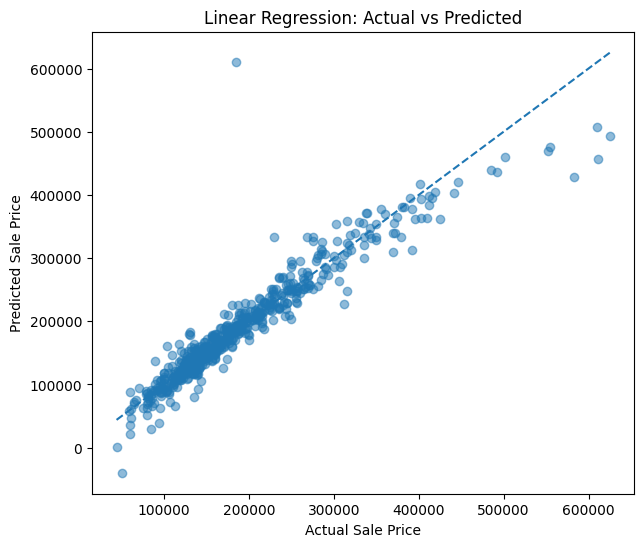

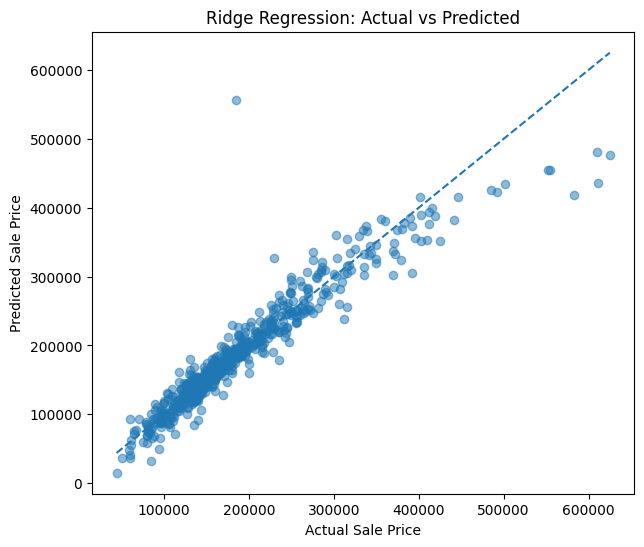

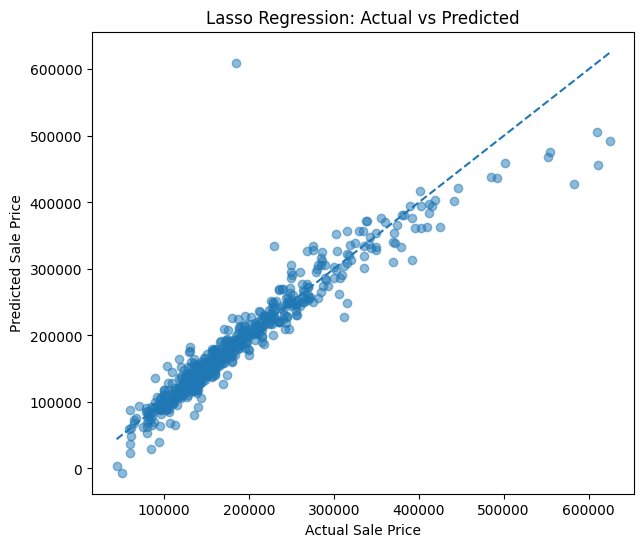

In [ ]:
for name, predictions_model in models.items():

    plt.figure(figsize=(7, 6))

    plt.scatter(
        y_test,
        predictions_model,
        alpha=0.5
    )

    # Perfect prediction line
    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        linestyle='--'
    )

    plt.xlabel('Actual Sale Price')
    plt.ylabel('Predicted Sale Price')
    plt.title(f'{name}: Actual vs Predicted')

    plt.show()

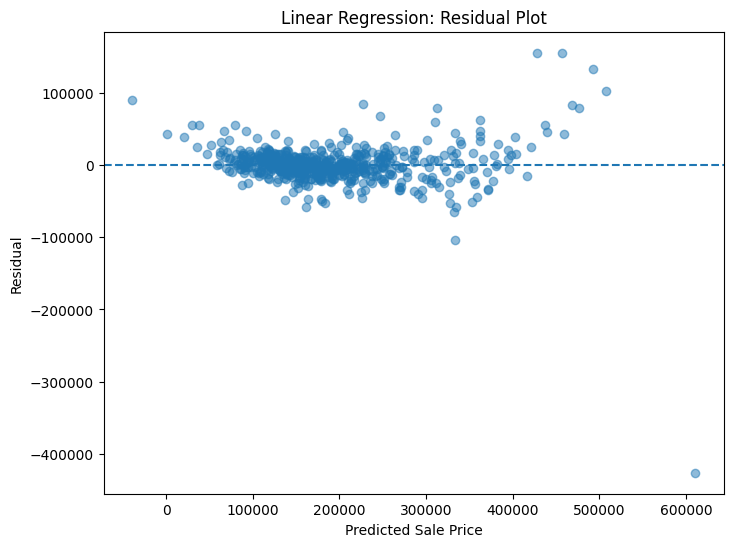

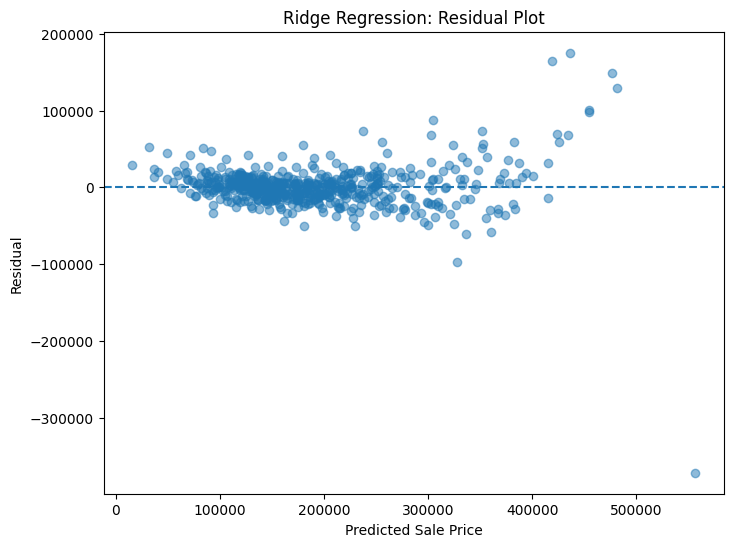

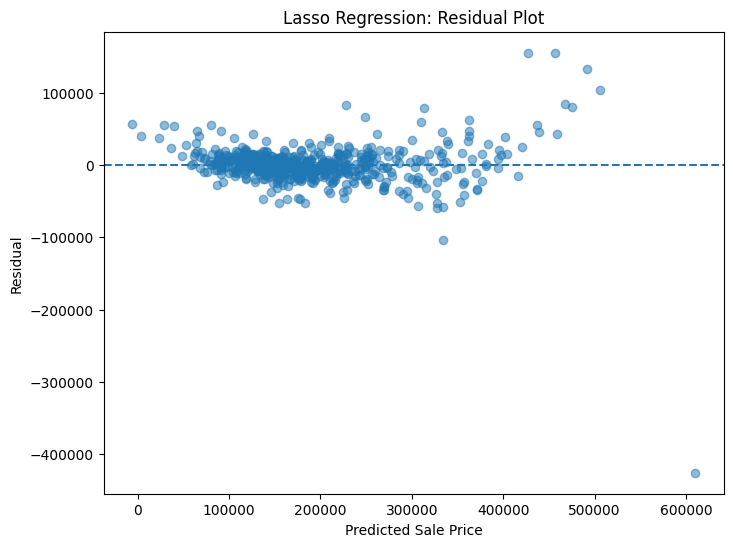

In [ ]:
for name, predictions_model in models.items():

    residuals = y_test - predictions_model

    plt.figure(figsize=(8, 6))

    plt.scatter(
        predictions_model,
        residuals,
        alpha=0.5
    )

    plt.axhline(
        y=0,
        linestyle='--'
    )

    plt.xlabel('Predicted Sale Price')
    plt.ylabel('Residual')
    plt.title(f'{name}: Residual Plot')

    plt.show()

#Feature Engineering

In [ ]:
df_clean['Total_SF'] = (df_clean['1st Flr SF'] + df_clean['2nd Flr SF'] + df_clean['Total Bsmt SF'])
df_clean['Total_Bathrooms'] = (df_clean['Full Bath'] + (0.5 * df_clean['Half Bath']) + df_clean['Bsmt Full Bath'] + (0.5 * df_clean['Bsmt Half Bath']))
df_clean['Total_Porch_SF'] = (df_clean['Open Porch SF'] + df_clean['Enclosed Porch'] + df_clean['3Ssn Porch'] + df_clean['Screen Porch'] + df_clean['Wood Deck SF'])
df_clean['House_Age'] = df_clean['Yr Sold'] - df_clean['Year Built']
df_clean['Remod_Age'] = df_clean['Yr Sold'] - df_clean['Year Remod/Add']

In [ ]:
df_clean[['Total_SF','Total_Bathrooms','Total_Porch_SF','House_Age','Remod_Age']].describe()

,Total_SF,Total_Bathrooms,Total_Porch_SF,House_Age,Remod_Age
count,2929.000000,2928.000000,2930.000000,2930.000000,2930.000000
mean,2546.832707,2.217896,182.891468,36.434130,23.523891
std,803.909695,0.807059,159.834420,30.291357,20.858846
min,334.000000,1.000000,0.000000,-1.000000,-2.000000
25%,2000.000000,1.500000,48.000000,7.000000,4.000000
50%,2452.000000,2.000000,165.000000,34.000000,15.000000
75%,2990.000000,2.500000,266.000000,54.000000,42.750000
max,11752.000000,7.000000,1424.000000,136.000000,60.000000


In [ ]:
df_clean.loc[
    df_clean['House_Age'] < 0,
    ['Year Built', 'Yr Sold', 'House_Age']
]

,Year Built,Yr Sold,House_Age
2180,2008,2007,-1


In [ ]:
df_clean.loc[
    df_clean['Remod_Age'] < 0,
    ['Year Remod/Add', 'Yr Sold', 'Remod_Age']
]

,Year Remod/Add,Yr Sold,Remod_Age
1702,2008,2007,-1
2180,2009,2007,-2
2181,2008,2007,-1


In [ ]:
print("Negative HouseAge:", (df_clean['House_Age'] < 0).sum())
print("Negative RemodAge:", (df_clean['Remod_Age'] < 0).sum())

Negative HouseAge: 1
Negative RemodAge: 3


In [ ]:
df_clean['Above_Ground_SF'] = df_clean['1st Flr SF'] + df_clean['2nd Flr SF']

#Experiment 2

In [ ]:
X = df_clean.drop(columns=['SalePrice'], axis=1)
y = df_clean['SalePrice']

X_train, X_test, y_train, y_test  = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train shape: ", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape: ", y_train.shape)
print("y_test shape: ", y_test.shape)

X_train shape:  (2344, 85)
X_test shape:  (586, 85)
y_train shape:  (2344,)
y_test shape:  (586,)


In [ ]:
new_features = ['Total_SF','Total_Bathrooms','Total_Porch_SF','House_Age','Remod_Age', 'Above_Ground_SF']

numeric_features = numeric_features + new_features
len(numeric_features)

40

In [ ]:
preprocessor_fe = ColumnTransformer([
    ('num', num_pipeline, numeric_features),
    ('noncat', noncat_pipeline, none_categories),
    ('cat', cat_pipeline, other_categorical)
])

linear_fe = Pipeline([
    ('preprocessor', preprocessor_fe),
    ('model', LinearRegression())
])

ridge_fe = Pipeline([
    ('preprocessor', preprocessor_fe),
    ('model', Lasso(alpha=1.0))
])

lasso_fe = Pipeline([
    ('preprocessor', preprocessor_fe),
    ('model', Ridge(alpha=1.0, max_iter=10000))
])

In [ ]:
linear_fe.fit(X_train, y_train)
lasso_fe.fit(X_train, y_train)
ridge_fe.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 256430642005.17648, tolerance: 1393681263.8331819
  model = cd_fast.sparse_enet_coordinate_descent(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Lot Frontage', 'Lot Area',
                                                   'Overall Qual',
                                                   'Overall Cond', 'Year Built',
                                                   'Year Remod/Add',
                                                   'Mas Vnr Area',
                                                   'BsmtFin SF 1',
                                                   'BsmtFin SF 2',
                                                   'Bsmt Unf SF',
                                                   'Total Bsmt SF',
                                                   '1st Flr SF', '2nd Flr SF',
                                                   'Low Qual Fin SF',
                                                   'Gr Li...
                                                   'Land Contour', 'Utilities',
                                                   'Lot Config', 'Land Slope',
                                                   'Neighborhood',
                                                   'Condition 1', 'Condition 2',
                                                   'Bldg Type', 'House Style',
                                                   'Roof Style', 'Roof Matl',
                                                   'Exterior 1st',
                                                   'Exterior 2nd', 'Exter Qual',
                                                   'Exter Cond', 'Foundation',
                                                   'Heating', 'Heating QC',
                                                   'Central Air', 'Electrical',
                                                   'Kitchen Qual', 'Functional',
                                                   'Paved Drive', 'Mo Sold',
                                                   'Sale Type',
                                                   'Sale Condition'])])),
                ('model', Lasso())])

In [ ]:
y_pred_linear_fe = linear_fe.predict(X_test)
y_pred_ridge_fe = ridge_fe.predict(X_test)
y_pred_lasso_fe = lasso_fe.predict(X_test)

In [ ]:
models_fe = {
    'Linear Regression': y_pred_linear_fe,
    'Ridge Regression': y_pred_ridge_fe,
    'Lasso Regression': y_pred_lasso_fe
}

results_fe = []

for name, predictions in models_fe.items():

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results_fe.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })

results_fe_df = pd.DataFrame(results_fe)

results_fe_df

,Model,MAE,RMSE,R2
0,Linear Regression,15735.787848,29274.939703,0.893107
1,Ridge Regression,15594.760398,28930.152015,0.895610
2,Lasso Regression,16038.727756,28658.463852,0.897561


In [ ]:
df_clean[new_features + ['SalePrice']].corr()['SalePrice'].sort_values(ascending=False)

,SalePrice
SalePrice,1.000000
Total_SF,0.793024
Above_Ground_SF,0.713588
Total_Bathrooms,0.635694
Total_Porch_SF,0.383506
Remod_Age,-0.534940
House_Age,-0.558907


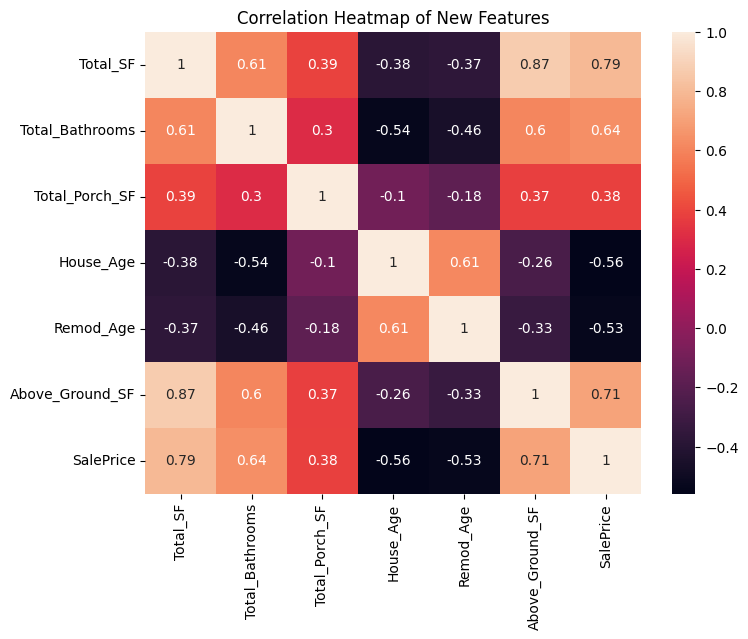

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean[new_features + ['SalePrice']].corr(), annot=True)
plt.title("Correlation Heatmap of New Features")
plt.show()

In [ ]:
feature_names = lasso_fe.named_steps[
    'preprocessor'
].get_feature_names_out()

coefficients = lasso_fe.named_steps[
    'model'
].coef_

lasso_coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

lasso_coef_df['AbsCoefficient'] = (
    lasso_coef_df['Coefficient'].abs()
)

lasso_coef_df.sort_values(
    'AbsCoefficient',
    ascending=False
).head(20)

,Feature,Coefficient,AbsCoefficient
231,cat__Roof Matl_ClyTile,-201877.751627,201877.751627
118,noncat__Misc Feature_Elev,-131669.335531,131669.335531
119,noncat__Misc Feature_Gar2,76229.377095,76229.377095
238,cat__Roof Matl_WdShngl,73398.714936,73398.714936
110,noncat__Pool QC_Gd,-72622.376894,72622.376894
108,noncat__Pool QC_Ex,71578.373461,71578.373461
177,cat__Neighborhood_GrnHill,69877.832665,69877.832665
121,noncat__Misc Feature_Othr,42317.536037,42317.536037
192,cat__Neighborhood_StoneBr,36832.110102,36832.110102
96,noncat__Garage Qual_Ex,36085.151492,36085.151492


In [ ]:
zero_coefficients = (
    lasso_coef_df['Coefficient'] == 0
).sum()

total_coefficients = len(lasso_coef_df)

print("Total coefficients:", total_coefficients)
print("Zero coefficients:", zero_coefficients)
print(
    "Percentage zeroed:",
    zero_coefficients / total_coefficients * 100
)

Total coefficients: 347
Zero coefficients: 0
Percentage zeroed: 0.0


#Experiment 3

In [ ]:
df_clean = df_clean.drop(columns=new_features)

In [ ]:
X = df_clean.drop(columns=['SalePrice'], axis=1)
y = df_clean['SalePrice']

X_train, X_test, y_train, y_test  = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.model_selection import GridSearchCV

ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

ridge_params = {
    'model__alpha': [0.01, 0.1, 1, 10, 100, 1000]
}

ridge_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_params,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Lot '
                                                                          'Frontage',
                                                                          'Lot '
                                                                          'Area',
                                                                          'Overall '
                                                                          'Qual',
                                                                          'Overall '
                                                                          'Cond',
                                                                          'Year '
                                                                          'Built',
                                                                          'Year '
                                                                          'Remod/Add',
                                                                          'Mas '
                                                                          'Vnr '
                                                                          'Area',
                                                                          'BsmtFin '
                                                                          'SF '
                                                                          '1',
                                                                          'BsmtFin '
                                                                          'SF '
                                                                          '2',
                                                                          'Bsmt '
                                                                          'Unf '
                                                                          'SF',...
                                                                          'Roof '
                                                                          'Matl',
                                                                          'Exterior '
                                                                          '1st',
                                                                          'Exterior '
                                                                          '2nd',
                                                                          'Exter '
                                                                          'Qual',
                                                                          'Exter '
                                                                          'Cond',
                                                                          'Foundation',
                                                                          'Heating',
                                                                          'Heating '
                                                                          'QC',
                                                                          'Central '
                                                                          'Air',
                                                                          'Electrical',
            

In [ ]:
print("Best alpha:", ridge_grid.best_params_)
print("Best CV RMSE:", -ridge_grid.best_score_)

Best alpha: {'model__alpha': 10}
Best CV RMSE: 27942.282994498975


In [ ]:
from sklearn.linear_model import Lasso

lasso_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso())
])

lasso_params = {
    'model__alpha': [0.01, 0.1, 1, 10, 100, 1000]
}

lasso_grid = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=lasso_params,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Lot '
                                                                          'Frontage',
                                                                          'Lot '
                                                                          'Area',
                                                                          'Overall '
                                                                          'Qual',
                                                                          'Overall '
                                                                          'Cond',
                                                                          'Year '
                                                                          'Built',
                                                                          'Year '
                                                                          'Remod/Add',
                                                                          'Mas '
                                                                          'Vnr '
                                                                          'Area',
                                                                          'BsmtFin '
                                                                          'SF '
                                                                          '1',
                                                                          'BsmtFin '
                                                                          'SF '
                                                                          '2',
                                                                          'Bsmt '
                                                                          'Unf '
                                                                          'SF',...
                                                                          'Roof '
                                                                          'Matl',
                                                                          'Exterior '
                                                                          '1st',
                                                                          'Exterior '
                                                                          '2nd',
                                                                          'Exter '
                                                                          'Qual',
                                                                          'Exter '
                                                                          'Cond',
                                                                          'Foundation',
                                                                          'Heating',
                                                                          'Heating '
                                                                          'QC',
                                                                          'Central '
                                                                          'Air',
                                                                          'Electrical',
            

In [ ]:
print("Best alpha:", lasso_grid.best_params_)
print("Best CV RMSE:", -lasso_grid.best_score_)

Best alpha: {'model__alpha': 100}
Best CV RMSE: 27581.991749112443


In [ ]:
best_lasso = lasso_grid.best_estimator_

feature_names = best_lasso.named_steps['preprocessor'].get_feature_names_out()
coefficients = best_lasso.named_steps['model'].coef_

lasso_coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

lasso_coef_df['AbsCoefficient'] = lasso_coef_df['Coefficient'].abs()

zero_count = (lasso_coef_df['Coefficient'] == 0).sum()
total_count = len(lasso_coef_df)

print("Total coefficients:", total_count)
print("Zero coefficients:", zero_count)
print("Percentage zeroed:", zero_count / total_count * 100)

print("\nLargest coefficients:")
display(
    lasso_coef_df
    .sort_values('AbsCoefficient', ascending=False)
    .head(20)
)

Total coefficients: 341
Zero coefficients: 227
Percentage zeroed: 66.56891495601172

Largest coefficients:


,Feature,Coefficient,AbsCoefficient
225,cat__Roof Matl_ClyTile,-278240.717275,278240.717275
112,noncat__Misc Feature_Elev,-60662.269487,60662.269487
102,noncat__Pool QC_Ex,38045.262202,38045.262202
186,cat__Neighborhood_StoneBr,37951.446652,37951.446652
179,cat__Neighborhood_NoRidge,35182.562041,35182.562041
232,cat__Roof Matl_WdShngl,27724.637644,27724.637644
113,noncat__Misc Feature_Gar2,26903.859971,26903.859971
14,num__Gr Liv Area,24156.986328,24156.986328
298,cat__Kitchen Qual_Ex,23553.294801,23553.294801
180,cat__Neighborhood_NridgHt,23447.880565,23447.880565


In [ ]:
best_ridge = ridge_grid.best_estimator_
best_lasso = lasso_grid.best_estimator_

best_ridge.fit(X_train, y_train)
best_lasso.fit(X_train, y_train)

ridge_pred = best_ridge.predict(X_test)
lasso_pred = best_lasso.predict(X_test)

In [ ]:
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
lasso_r2 = r2_score(y_test, lasso_pred)

print("Tuned Ridge")
print("MAE :", ridge_mae)
print("RMSE:", ridge_rmse)
print("R²  :", ridge_r2)

print("\nTuned Lasso")
print("MAE :", lasso_mae)
print("RMSE:", lasso_rmse)
print("R²  :", lasso_r2)

Tuned Ridge
MAE : 16472.382468725744
RMSE: 28872.08749646171
R²  : 0.8960283812972529

Tuned Lasso
MAE : 16087.563766246865
RMSE: 28619.062788676
R²  : 0.8978427367119656


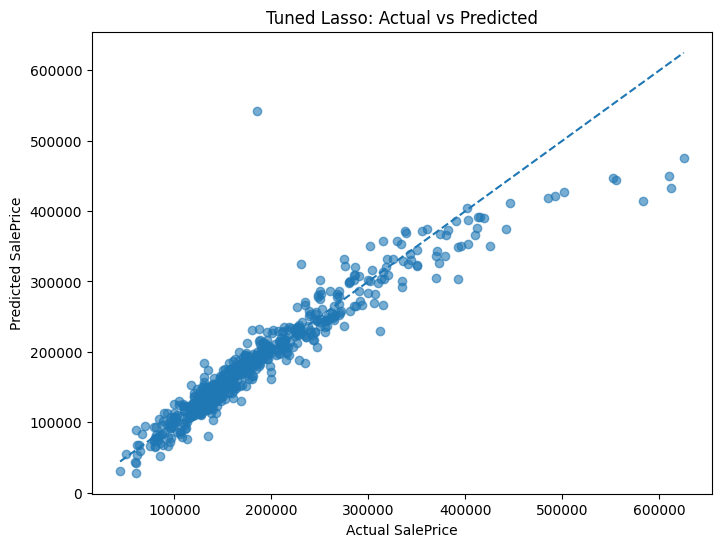

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, lasso_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Tuned Lasso: Actual vs Predicted")

plt.show()

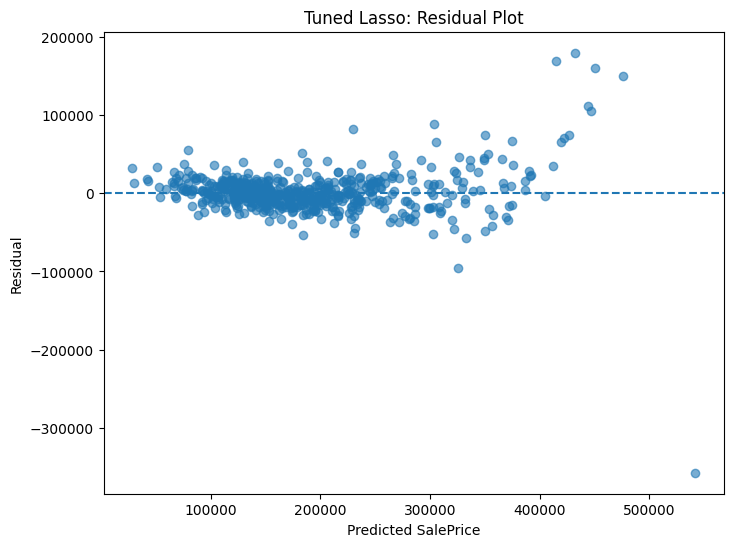

In [ ]:
residuals = y_test - lasso_pred

plt.figure(figsize=(8, 6))

plt.scatter(lasso_pred, residuals, alpha=0.6)

plt.axhline(0, linestyle='--')

plt.xlabel("Predicted SalePrice")
plt.ylabel("Residual")
plt.title("Tuned Lasso: Residual Plot")

plt.show()

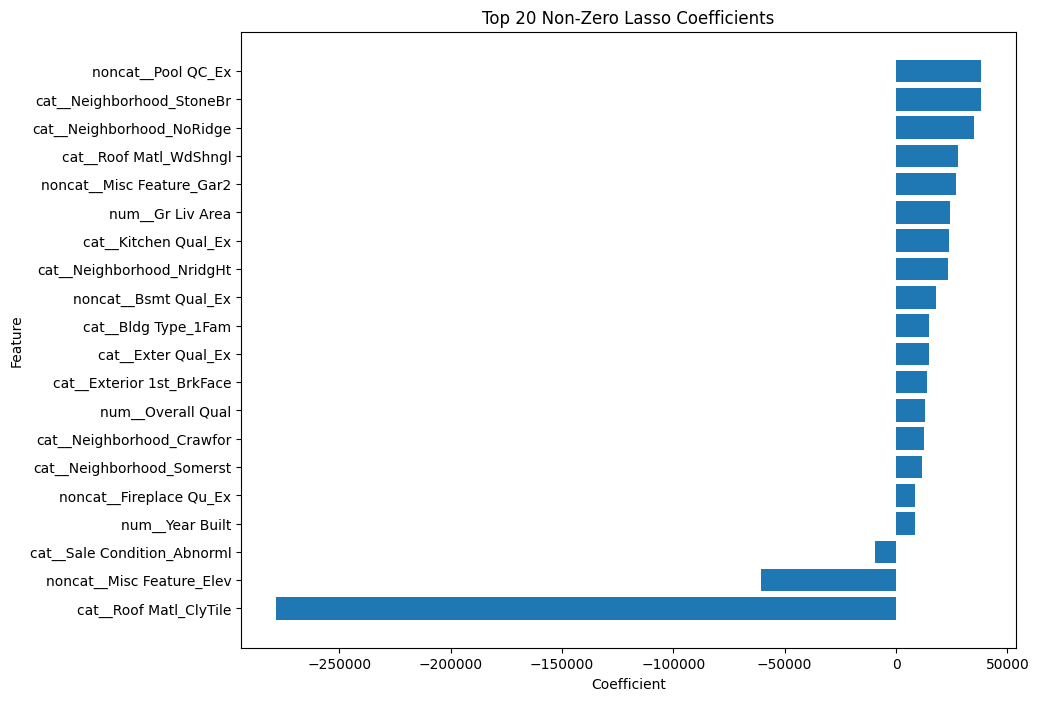

In [ ]:
nonzero_coef = lasso_coef_df[
    lasso_coef_df['Coefficient'] != 0
].copy()

nonzero_coef = (
    nonzero_coef
    .sort_values('AbsCoefficient', ascending=False)
    .head(20)
    .sort_values('Coefficient')
)

plt.figure(figsize=(10, 8))

plt.barh(
    nonzero_coef['Feature'],
    nonzero_coef['Coefficient']
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top 20 Non-Zero Lasso Coefficients")

plt.show()

In [ ]:
df_clean['Roof Matl'].value_counts()

,count
Roof Matl,
CompShg,2887
Tar&Grv,23
WdShake,9
WdShngl,7
Membran,1
ClyTile,1
Roll,1
Metal,1


In [ ]:
print("Misc Feature:")
print(df_clean['Misc Feature'].value_counts())

print("\nPool QC:")
print(df_clean['Pool QC'].value_counts())

print("\nNeighborhood:")
print(df_clean['Neighborhood'].value_counts())

Misc Feature:
Misc Feature
Shed    95
Gar2     5
Othr     4
Elev     1
TenC     1
Name: count, dtype: int64

Pool QC:
Pool QC
Ex    4
Gd    4
TA    3
Fa    2
Name: count, dtype: int64

Neighborhood:
Neighborhood
NAmes      443
CollgCr    267
OldTown    239
Edwards    194
Somerst    182
NridgHt    166
Gilbert    165
Sawyer     151
NWAmes     131
SawyerW    125
Mitchel    114
BrkSide    108
Crawfor    103
IDOTRR      93
Timber      72
NoRidge     71
StoneBr     51
SWISU       48
ClearCr     44
MeadowV     37
BrDale      30
Blmngtn     28
Veenker     24
NPkVill     23
Blueste     10
Greens       8
GrnHill      2
Landmrk      1
Name: count, dtype: int64


#Log Transformation

In [ ]:
y_train_log = np.log1p(y_train)

In [ ]:
lasso_log = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(alpha=100, max_iter=50000))
])

lasso_log.fit(X_train, y_train_log)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Lot Frontage', 'Lot Area',
                                                   'Overall Qual',
                                                   'Overall Cond', 'Year Built',
                                                   'Year Remod/Add',
                                                   'Mas Vnr Area',
                                                   'BsmtFin SF 1',
                                                   'BsmtFin SF 2',
                                                   'Bsmt Unf SF',
                                                   'Total Bsmt SF',
                                                   '1st Flr SF', '2nd Flr SF',
                                                   'Low Qual Fin SF',
                                                   'Gr Li...
                                                   'Land Contour', 'Utilities',
                                                   'Lot Config', 'Land Slope',
                                                   'Neighborhood',
                                                   'Condition 1', 'Condition 2',
                                                   'Bldg Type', 'House Style',
                                                   'Roof Style', 'Roof Matl',
                                                   'Exterior 1st',
                                                   'Exterior 2nd', 'Exter Qual',
                                                   'Exter Cond', 'Foundation',
                                                   'Heating', 'Heating QC',
                                                   'Central Air', 'Electrical',
                                                   'Kitchen Qual', 'Functional',
                                                   'Paved Drive', 'Mo Sold',
                                                   'Sale Type',
                                                   'Sale Condition'])])),
                ('model', Lasso(alpha=100, max_iter=50000))])

In [ ]:
y_pred_log = lasso_log.predict(X_test)

In [ ]:
lasso_log_pred = np.expm1(y_pred_log)

In [ ]:
log_mae = mean_absolute_error(y_test, lasso_log_pred)
log_rmse = np.sqrt(mean_squared_error(y_test, lasso_log_pred))
log_r2 = r2_score(y_test, lasso_log_pred)

print("Log-target Lasso")
print("MAE :", log_mae)
print("RMSE:", log_rmse)
print("R²  :", log_r2)

Log-target Lasso
MAE : 63733.06338709982
RMSE: 92955.49761809046
R²  : -0.07772658322586468


#Log transformation 2

In [ ]:
y_train_log = np.log1p(y_train)

In [ ]:
lasso_log_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso())
])

lasso_log_params = {
    'model__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]
}

lasso_log_grid = GridSearchCV(
    estimator=lasso_log_pipeline,
    param_grid=lasso_log_params,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

lasso_log_grid.fit(X_train, y_train_log)

print("Best alpha:", lasso_log_grid.best_params_)
print("Best CV RMSE:", -lasso_log_grid.best_score_)

Best alpha: {'model__alpha': 0.001}
Best CV RMSE: 0.14179420674469262


In [ ]:
best_lasso_log = lasso_log_grid.best_estimator_

y_pred_log = best_lasso_log.predict(X_test)

# Convert back to original price scale
lasso_log_pred = np.expm1(y_pred_log)

log_mae = mean_absolute_error(y_test, lasso_log_pred)
log_rmse = np.sqrt(mean_squared_error(y_test, lasso_log_pred))
log_r2 = r2_score(y_test, lasso_log_pred)

print("Tuned Log-target Lasso")
print("MAE :", log_mae)
print("RMSE:", log_rmse)
print("R²  :", log_r2)

Tuned Log-target Lasso
MAE : 15648.059464930455
RMSE: 33397.42087138051
R²  : 0.8608816897046181


In [ ]:
error_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': lasso_pred
})

error_df['Residual'] = error_df['Actual'] - error_df['Predicted']
error_df['AbsoluteError'] = error_df['Residual'].abs()

error_df.sort_values(
    'AbsoluteError',
    ascending=False
).head(10)

,Actual,Predicted,Residual,AbsoluteError
2181,184750,541849.197418,-357099.197418,357099.197418
44,611657,432147.065426,179509.934574,179509.934574
433,582933,414521.879534,168411.120466,168411.120466
432,610000,450245.723854,159754.276146,159754.276146
2445,625000,475842.963824,149157.036176,149157.036176
423,555000,443606.218463,111393.781537,111393.781537
456,552000,446799.284817,105200.715183,105200.715183
944,230000,325357.607003,-95357.607003,95357.607003
1559,392500,303929.156386,88570.843614,88570.843614
1538,311500,229719.672725,81780.327275,81780.327275


#Conclusion

Three linear regression approaches—Linear Regression, Ridge Regression, and Lasso Regression—were implemented using a leakage-safe preprocessing pipeline with numerical imputation and scaling and categorical one-hot encoding. Baseline and regularized models were compared using MAE, RMSE, and R². Hyperparameter optimization using 5-fold cross-validation selected α=10 for Ridge and α=100 for Lasso. The tuned Lasso achieved an RMSE of approximately $28.6K and an R² of 0.898 on the held-out test set. It also demonstrated substantial embedded feature selection, reducing 341 transformed features to 114 non-zero coefficients. Feature engineering did not consistently improve performance, while a log-transformed target reduced MAE but increased RMSE and reduced R². Residual analysis showed that the linear models struggled particularly with high-priced properties, suggesting that nonlinear relationships and feature interactions are not fully captured by the linear model family.

#Regression Project Steps

##Data preparation
* EDA
* Missing-value analysis
* Numerical/categorical feature handling
* One-hot encoding
* Feature scaling
* Train/test separation
* Leakage prevention

##Regression
- Linear Regression
- Ridge Regression
- Lasso Regression

##Model selection
- MAE
- RMSE
- R²
- 5-fold cross-validation
- GridSearchCV
- Hyperparameter tuning

##Regularization
- L1 vs L2
- Effect of alpha
- Lasso embedded feature selection

##Model diagnostics
- Actual vs predicted
- Residual analysis
- Largest prediction errors
- Rare-category analysis

##Experimentation
- Feature engineering
- Log-target transformation
- Comparison of experimental results